In [2]:
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')

from preprocessing import *
from models import  *

/home/sr100@hsg.privat/x-med/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dfs = get_dfs(os.path.dirname(os.getcwd()))
static_df = create_static_df(dfs)

Total number of patients: 3433
Patients with graft loss: 621


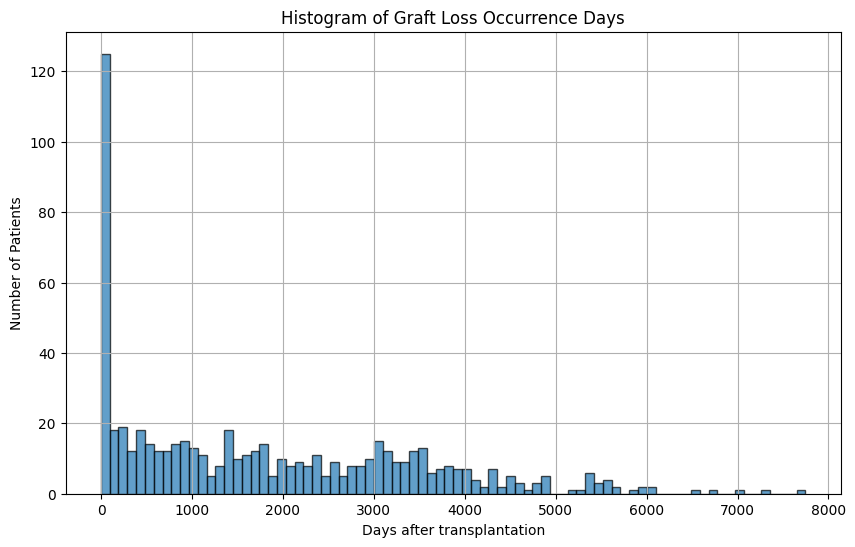

AttributeError: 'Series' object has no attribute 'isnan'

In [9]:
total_patients = len(static_df)

# Patients with graft loss
graft_loss_patients = static_df['loss_rel_days'].notna().sum()

# Print summary
print(f"Total number of patients: {total_patients}")
print(f"Patients with graft loss: {graft_loss_patients}")

# Plot histogram of graft loss occurrence days
graft_loss_days = static_df['loss_rel_days'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(graft_loss_days, bins=80, edgecolor='black', alpha=0.7)
plt.title('Histogram of Graft Loss Occurrence Days')
plt.xlabel('Days after transplantation')
plt.ylabel('Number of Patients')
plt.grid(True)
plt.show()

Total number of patients: 3433
Patients who died: 1061


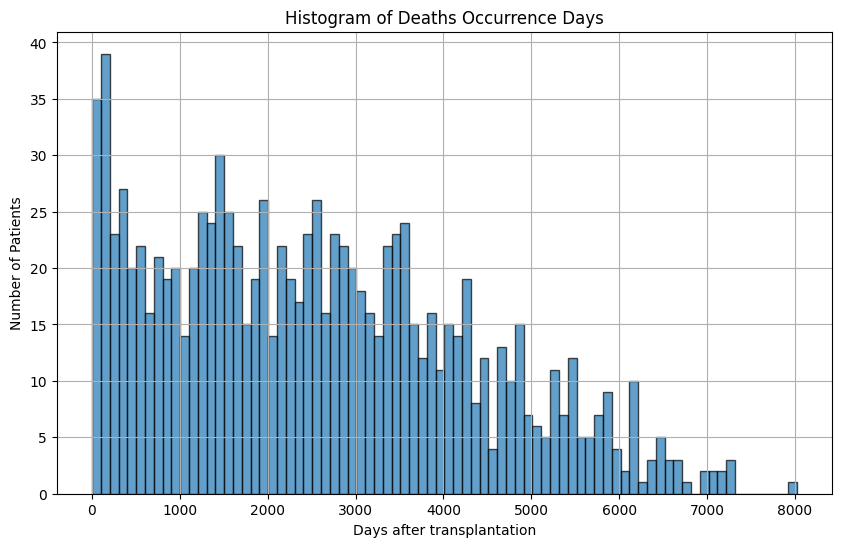

In [6]:
total_patients = len(static_df)

dead_patients = static_df['death_rel_days'].notna().sum()

# Print summary
print(f"Total number of patients: {total_patients}")
print(f"Patients who died: {dead_patients}")

# Plot histogram of graft loss occurrence days
death_rel_days = static_df['death_rel_days'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(death_rel_days, bins=80, edgecolor='black', alpha=0.7)
plt.title('Histogram of Deaths Occurrence Days')
plt.xlabel('Days after transplantation')
plt.ylabel('Number of Patients')
plt.grid(True)
plt.show()

In [ ]:
medication_df = create_medication_df(dfs)
vitals_ca, vitals_lab = create_vitals_df(dfs)
ts_data = create_ts_data(vitals_ca, vitals_lab, medication_df, merge_lab=True, merge_med=True)
#notes = create_notes_df(dfs, filename='../data/embeddings/emb_gte_full.npy')
notes = create_notes_df(dfs, filename=None)

Unique patients in medication: 3335
Removing patients that are not in static_df
Unique patients in clinical assessments: 3296
Average entries per patient 78.9
Unique patients in clinical assessments: 3465
Removing patients that are not in static_df
Unique patients in clinical assessments: 3423
Average entries per patient 61.16155419222904
Unique patients in lab df: 3460
Removing patients that are not in static_df
Unique patients in lab df: 3410
Average entries per patient 472.2140762463343
3431


In [30]:
notes.iloc[9]['text']

'Farbkodierte Dopplersonographie und Power-Doppler des Nierentransplantates vom 30.12.2003 :  Klinik:  NTX-Verlaufskontrolle. Befund:  Nierentransplantat im linken Unterbauch, Volumen aktuell ca. 315cm3. Parenchymsaum nicht verschmälert und von regelrechter Echogenität. Dopplersonographisch zeigt sich eine Durchblutung mit RI = 0,90-1,0, gemessen an mehreren Segmentarterien. Kein Nachweis fokaler Perfusionsausfälle. Nierenhilus und Anastomosenregion regelrecht. Aktuell Darstellung eines 9,6x5,6cm großen Hämatomes, welches fingerförmig einen Polbereich umgreift. Ergebnis: Volumen- und RI-Zunahme sowie perirenales Hämatom. Nach Rücksprache mit den Kollegen der Station z.Z. nur geringer Hb-Abfall bei stabiler Funktion der Niere.  Bei klinischem V.a. aktive Blutung weiterführende Diagnostik im CT empfohlen. Farbkodierte Dopplersonographie und Power-Doppler des Nierentransplantates vom 30.12.2003 :  Klinik:  NTX-Verlaufskontrolle. Befund:  Nierentransplantat im linken Unterbauch, Volumen ak

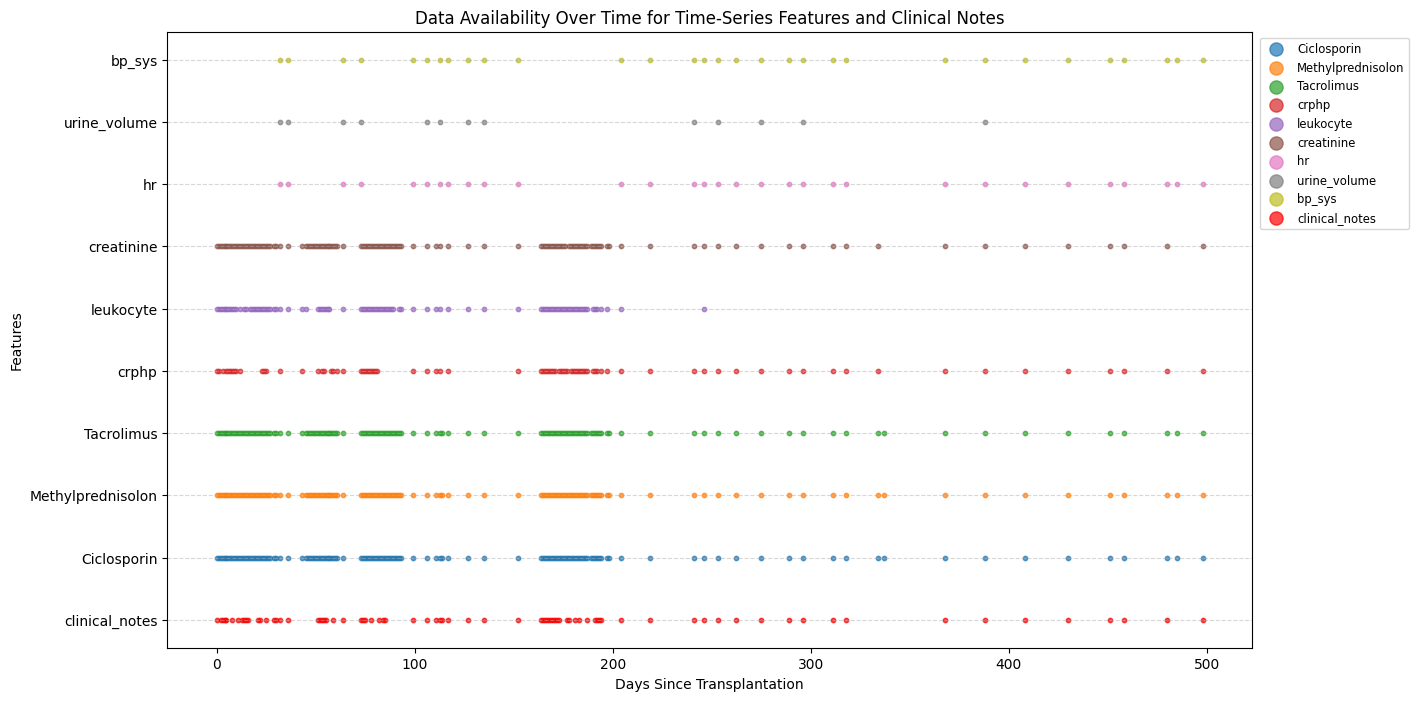

In [24]:
ts_features = CONFIG['ts_features'].copy()

ts_features.remove('diuresis_time')
ts_features.remove('bp_dia')
ts_features.remove('weight')
ts_features.remove('temperature')

ts_features = ts_features[::-1]  

patient_id = 299 # 299
max_days = 500

patient_ts_data = ts_data[ts_data['patient_id'] == patient_id]
data_availability = patient_ts_data[ts_features].notna()
data_availability['rel_days'] = patient_ts_data['rel_days']

patient_notes = notes[notes['patient_id'] == patient_id]

# Get the days with clinical notes
notes_days = patient_notes['rel_days'].unique()

# Limit data to max_days
data_availability = data_availability[data_availability['rel_days'] <= max_days]
notes_days = notes_days[notes_days <= max_days]

# Plot data availability over time for all features
plt.figure(figsize=(14, 8))

# Plot time-series features availability
for idx, feature in enumerate(ts_features):
    feature_data = data_availability[['rel_days', feature]]
    available_days = feature_data[feature_data[feature]].rel_days
    plt.scatter(available_days, [idx] * len(available_days), label=feature, s=10, alpha=0.7)

# Add clinical_notes feature at the bottom
plt.scatter(notes_days, [-1] * len(notes_days), label='clinical_notes', s=10, alpha=0.7, color='red')

# Customize plot
plt.yticks(range(-1, len(ts_features)), ['clinical_notes'] + ts_features)
plt.xlabel('Days Since Transplantation')
plt.ylabel('Features')
plt.title('Data Availability Over Time for Time-Series Features and Clinical Notes')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize='small', markerscale=3, bbox_to_anchor=(1.15, 1))
plt.savefig('../plots/data_avail.png')
plt.show()
